Propagating FULL PERTURBATIONS MOLNIYA for 30 days...

  MISSION ANALYSIS: HEO MOLNIYA AFTER 30 DAYS
  Model: 10x10 Gravity, Atm Drag, SRP, Luni-Solar Third Body
1. SEMI-MAJOR AXIS (a)
   Initial: 26562.000 km
   Final:   26690.544 km
   Delta:   128544.46 meters (128.544455 km) (Periodic oscillation induced by Third Body)
--------------------------------------------------------------------
2. ECCENTRICITY (e)
   Initial: 0.740000
   Final:   0.740805
   Delta:   0.000805 (Third Body perturbations dominant)
--------------------------------------------------------------------
3. INCLINATION (i)
   Initial: 63.43490 deg
   Final:   63.45367 deg
   Delta:   0.01877 deg (Oscillations due to Third Body/J2)
--------------------------------------------------------------------
4. RAAN (Ω)
   Initial: 0.000 deg
   Final:   355.413 deg (Standard 360 Modulo)
            -4.587 deg (Real Propagated Value)
   Delta:   -4.587 deg (Normalized real drift)
----------------------------------------------

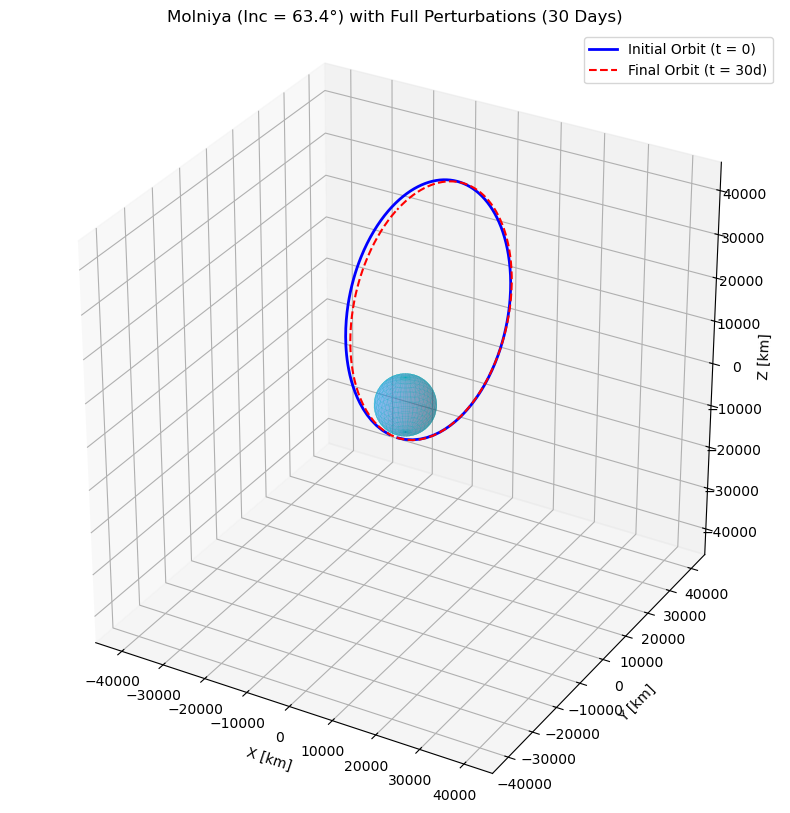

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from orekit import JArray_double

# ==========================================
# 1. OREKIT ENVIRONMENT INITIALIZATION
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions
from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState

from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel, ThirdBodyAttraction
from org.orekit.forces.drag import DragForce, IsotropicDrag
from org.orekit.models.earth.atmosphere import HarrisPriester
from org.orekit.bodies import CelestialBodyFactory, OneAxisEllipsoid
from org.orekit.forces.radiation import SolarRadiationPressure, IsotropicRadiationSingleCoefficient

# ==========================================
# 2. TIME AND FRAMES DEFINITION
# ==========================================
utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 8, 4, 12, 0, 0.0, utc)

inertial_frame = FramesFactory.getEME2000()
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True)
earth_shape = OneAxisEllipsoid(Constants.WGS84_EARTH_EQUATORIAL_RADIUS, 
                               Constants.WGS84_EARTH_FLATTENING, 
                               earth_frame)
mu = Constants.WGS84_EARTH_MU

# ==========================================
# 3. MOLNIYA ORBIT CREATION
# ==========================================
a = 26562000.0  # Semi-major axis for a 12h period
e = 0.74        # Highly elliptical
i = math.radians(63.4349)  # Critical inclination to "freeze" the argument of perigee
omega = math.radians(270.0) # Perigee at South, Apogee (peak) at North
raan = math.radians(0.0)
lM = math.radians(0.0)

initial_orbit = KeplerianOrbit(a, e, i, omega, raan, lM, PositionAngleType.MEAN, inertial_frame, initial_date, mu)
initial_state = SpacecraftState(initial_orbit, 1000.0)

# ==========================================
# 4. PROPAGATOR CONFIGURATION
# ==========================================
min_step = 0.001
max_step = 300.0
position_tolerance = 10.0 
tolerances = NumericalPropagator.tolerances(position_tolerance, initial_orbit, initial_orbit.getType())
abs_tolerance = JArray_double.cast_(tolerances[0])
rel_tolerance = JArray_double.cast_(tolerances[1])

integrator = DormandPrince853Integrator(min_step, max_step, abs_tolerance, rel_tolerance)
propagator = NumericalPropagator(integrator)
propagator.setInitialState(initial_state)
ephemeris_generator = propagator.getEphemerisGenerator()

# ==========================================
# 5. ADDING ALL PERTURBATIONS
# ==========================================
gravity_provider = GravityFieldFactory.getNormalizedProvider(10, 10)
propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, gravity_provider))

sun = CelestialBodyFactory.getSun()
moon = CelestialBodyFactory.getMoon()
propagator.addForceModel(ThirdBodyAttraction(sun))
propagator.addForceModel(ThirdBodyAttraction(moon))

atmosphere = HarrisPriester(sun, earth_shape)
propagator.addForceModel(DragForce(atmosphere, IsotropicDrag(15.0, 2.2)))

propagator.addForceModel(SolarRadiationPressure(sun, earth_shape, IsotropicRadiationSingleCoefficient(15.0, 1.8)))

# ==========================================
# 6. PROPAGATION (30 DAYS)
# ==========================================
days = 30.0
duration = days * 24.0 * 3600.0  
final_date = initial_date.shiftedBy(duration)

print(f"Propagating FULL PERTURBATIONS MOLNIYA for {int(days)} days...")
final_state = propagator.propagate(final_date)
orbit_30d = KeplerianOrbit(final_state.getOrbit())

# ==========================================
# 7. MISSION ANALYSIS REPORT
# ==========================================
a_fin = orbit_30d.getA()
e_fin = orbit_30d.getE()
i_fin = math.degrees(orbit_30d.getI())

raan_fin_raw = math.degrees(orbit_30d.getRightAscensionOfAscendingNode())
omega_fin_raw = math.degrees(orbit_30d.getPerigeeArgument())

raan_fin_mod = raan_fin_raw % 360.0
omega_fin_mod = omega_fin_raw % 360.0

delta_raan = (raan_fin_raw - math.degrees(raan) + 180.0) % 360.0 - 180.0
delta_omega = (omega_fin_raw - math.degrees(omega) + 180.0) % 360.0 - 180.0

print("\n====================================================================")
print(f"  MISSION ANALYSIS: HEO MOLNIYA AFTER {int(days)} DAYS")
print("  Model: 10x10 Gravity, Atm Drag, SRP, Luni-Solar Third Body")
print("====================================================================")
print(f"1. SEMI-MAJOR AXIS (a)")
print(f"   Initial: {a/1000:.3f} km")
print(f"   Final:   {a_fin/1000:.3f} km")
print(f"   Delta:   {(a_fin - a):.2f} meters ({(a_fin - a)/1000:.6f} km) (Periodic oscillation induced by Third Body)")
print("--------------------------------------------------------------------")
print(f"2. ECCENTRICITY (e)")
print(f"   Initial: {e:.6f}")
print(f"   Final:   {e_fin:.6f}")
print(f"   Delta:   {e_fin - e:.6f} (Third Body perturbations dominant)")
print("--------------------------------------------------------------------")
print(f"3. INCLINATION (i)")
print(f"   Initial: {math.degrees(i):.5f} deg")
print(f"   Final:   {i_fin:.5f} deg")
print(f"   Delta:   {i_fin - math.degrees(i):.5f} deg (Oscillations due to Third Body/J2)")
print("--------------------------------------------------------------------")
print(f"4. RAAN (\u03A9)")
print(f"   Initial: {math.degrees(raan):.3f} deg")
print(f"   Final:   {raan_fin_mod:.3f} deg (Standard 360 Modulo)")
print(f"            {raan_fin_raw:.3f} deg (Real Propagated Value)")
print(f"   Delta:   {delta_raan:.3f} deg (Normalized real drift)")
print("--------------------------------------------------------------------")
print(f"5. ARGUMENT OF PERIGEE (\u03C9) -> FROZEN ORBIT")
print(f"   Initial: {math.degrees(omega):.3f} deg")
print(f"   Final:   {omega_fin_mod:.3f} deg (Standard 360 Modulo)")
print(f"            {omega_fin_raw:.3f} deg (Real Propagated Value)")
print(f"   Delta:   {delta_omega:.3f} deg")
print("   Result: Even with Sun, Moon, Atmosphere, and 10x10 Gravity, \u03C9 remains LOCKED at ~270°")
print("====================================================================\n")

# ==========================================
# 8. 3D VISUALIZATION
# ==========================================
print("Generating 3D plot...")
ephemeris = ephemeris_generator.getGeneratedEphemeris()
orbital_period = 43200.0  

def extract_orbit(start_time, end_time):
    times = np.linspace(start_time, end_time, 250)
    x, y, z = [], [], []
    for t in times:
        current_date = initial_date.shiftedBy(float(t))
        pos = ephemeris.propagate(current_date).getPVCoordinates().getPosition()
        x.append(pos.getX() / 1000.0)
        y.append(pos.getY() / 1000.0)
        z.append(pos.getZ() / 1000.0)
    return x, y, z

x0, y0, z0 = extract_orbit(0, orbital_period)                                  
x30, y30, z30 = extract_orbit(duration - orbital_period, duration)              

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
R_E_km = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0
x_earth = R_E_km * np.cos(u) * np.sin(v)
y_earth = R_E_km * np.sin(u) * np.sin(v)
z_earth = R_E_km * np.cos(v)
ax.plot_surface(x_earth, y_earth, z_earth, color='dodgerblue', alpha=0.3, edgecolor='c', linewidth=0.2)

ax.plot(x0, y0, z0, color='blue', linewidth=2.0, label='Initial Orbit (t = 0)')
ax.plot(x30, y30, z30, color='red', linewidth=1.5, linestyle='dashed', label='Final Orbit (t = 30d)')

lim = R_E_km + 40000 
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_box_aspect([1,1,1]) 

ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('Molniya (Inc = 63.4°) with Full Perturbations (30 Days)')
ax.legend(loc='upper right')

plt.show()